## Entrega 3 - Redes Neurais

Aluno: Paulo Henrique L. Dantas | 221022408

**Definição do Problema:** Stellar Classification Dataset - SDSS17 \

Usar o dataset e treinar um modelo de redes neurais para classificar estrelas, galáxias e quasar  \
[link-dataset](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)


## Analisando o Dataset

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   
5  1.237680e+18  340.995121  20.589476  23.48827  23.33776  21.32195   
6  1.237679e+18   23.234926  11.418188  21.46973  21.17624  20.92829   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301    

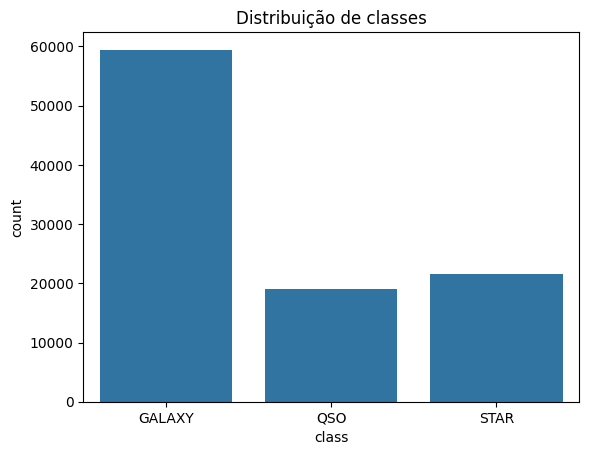

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os dados do dataset
df = pd.read_csv("/content/star_classification.csv")

# Visualizando o dataset
print(df.head(7))
print("\n")

# Verificando informações do dataset
print("Informações do dataset: ")
print(df.info())
print("\n")

print("Colunas: ")
print(df.columns)
print("\n")

print("Verificando se há valores nulos nas colunas: ")
print(df.isnull().sum())

# Verificando distribuição de classes
print(df['class'].value_counts())
sns.countplot(data=df, x='class')
plt.title("Distribuição de classes")
plt.show()

## Interpretações

Visão geral

- O dataset não possui valores nulos, o que ajuda na normalização
- Entender como cada feature se assemelha a cada classe: `galaxy`, `qso`, `star`
- O dataset possui apenas valores numéricos, excluindo as classes de classificação
- A maior classe de classificação que obtemos através do gráfico são as galáxias

O documento possui as seguintes colunas:

- `obj_ID`, `alpha`, `delta`, `u`, `g`, `r`, `i`, `z`: coordenadas e bandas espectrais (u, g, r, i, z),
- `run_ID`, `rerun_ID`, `cam_col`, `field_ID`: informações técnicas, redshift: desvio para o vermelho (muito útil para diferenciar galáxias e quasares),
- `plate`, `MJD`, `fiber_ID`: identificadores técnicos,
- `class`: variável-alvo (Galaxy, QSO ou Star).

Distribuição de classes

- `Galaxy` é a classe mais presente,
- `Star` vem em segundo,
- `QSO` (quasar) é a menos frequente.

Dessa forma podemos balancear os pesos dos neurônios com base no nível de ocorrência de cada classe


## Pré processamento dos arquivos

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separar as features e lebals
X = df.drop(columns=['class', 'obj_ID'])
y = df['class']

# Codificando a variável alvo
le = LabelEncoder()
y = le.fit_transform(y)

# Normaliando os dados com StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Separar os dados em teste e treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

As classes foram transformadas em valores numéricos com o LabelEncoder:

    GALAXY → 0

    QSO → 1

    STAR → 2


| Classe | Código | Quantidade |
| ------ | ------ | ---------- |
| GALAXY | 0      | 59.445     |
| QSO    | 1      | 18.961     |
| STAR   | 2      | 21.594     |

```python
class_weights_dict = {
    0: 0.56,  # GALAXY
    1: 1.76,  # QSO
    2: 1.54   # STAR
}
```

**Obs: Esses pesos significam que o modelo vai "valorizar mais" QSO e STAR durante o treinamento, equilibrando as chances de acerto mesmo com menos exemplos**

## Construindo a rede neural com tensorFlow

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Criando modelo simples
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# Compilando o modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Treinar o modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight={
        0: 0.56,  # GALAXY
        1: 1.76,  # QSO
        2: 1.54   # STAR
    }
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8221 - loss: 0.3838 - val_accuracy: 0.9517 - val_loss: 0.1691
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9483 - loss: 0.1547 - val_accuracy: 0.9490 - val_loss: 0.1548
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9544 - loss: 0.1282 - val_accuracy: 0.9624 - val_loss: 0.1297
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9584 - loss: 0.1193 - val_accuracy: 0.9614 - val_loss: 0.1304
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9589 - loss: 0.1186 - val_accuracy: 0.9549 - val_loss: 0.1461
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9611 - loss: 0.1107 - val_accuracy: 0.9475 - val_loss: 0.1691
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9615 - loss: 0.1122 - val_accuracy: 0.9609 - val_loss: 0.1309
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9614 - loss: 0.1094 - val_accu

## Avaliação do Modelo

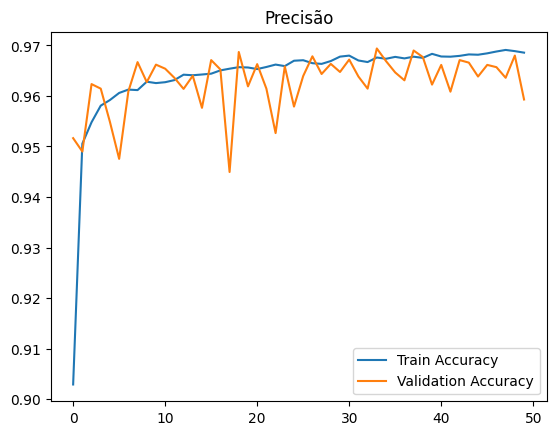

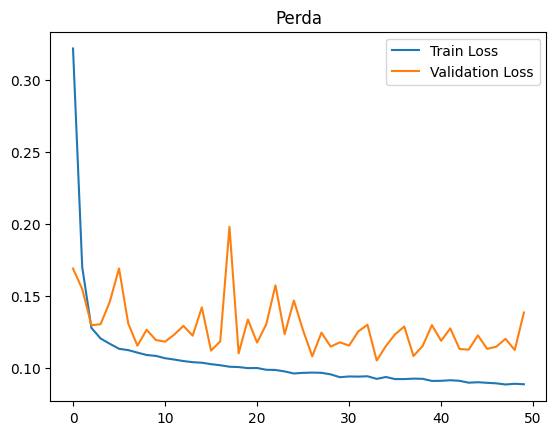

In [7]:
# Motando gráfico de perda e precisão
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Precisão")
plt.show()

# Gráfico de perda
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Perda")
plt.show()

## Interpretação

**Gráfico de Precisão**

- Curva de treino (Train Accuracy): cresce continuamente e estabiliza por volta de 97%.
- Curva de validação (Validation Accuracy): apresenta variações, mas também gira em torno de 96.5% a 97%.
- Ambas se mantêm próximas ao longo do tempo.

O modelo está generalizando bem, não há grande divergência entre treino e validação.
Não há sinais claros de overfitting, pois o desempenho na validação não caiu de forma significativa.

**Gráfico de Perda**

-Train Loss diminui consistentemente e estabiliza em torno de 0.08.
- Validation Loss oscila mais, com alguns picos ocasionais, mas também mantém média próxima de 0.1 a 0.13.

O modelo consegue reduzir bem o erro no treino e mantém a perda na validação em um nível baixo.

Os picos no val_loss podem indicar instabilidade causada por:

    Pequenos grupos de validação com menos exemplos das classes minoritárias,

    Ou oscilações naturais quando se usa class_weight.


| Aspecto           | Observação                                                                 |
| ----------------- | -------------------------------------------------------------------------- |
|  Acurácia       | Alta e estável (\~97%) para treino e validação                             |
|  Perda (loss)   | Baixa e estável, com variações leves na validação                          |
|  Overfitting?   | **Não detectado** — modelo se mantém estável após 50 épocas                |
|  Balanceamento  | Funcionou bem — modelo não sobreajustou à classe majoritária (Galaxy)      |


## Testando modelo

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step


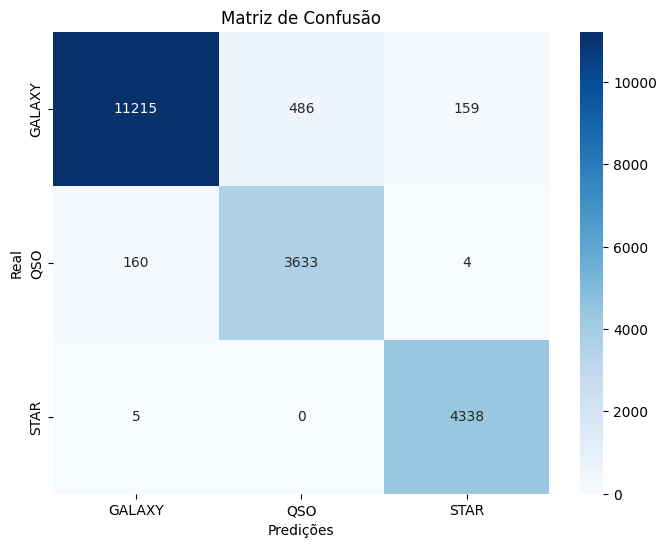

              precision    recall  f1-score   support

      GALAXY       0.99      0.95      0.97     11860
         QSO       0.88      0.96      0.92      3797
        STAR       0.96      1.00      0.98      4343

    accuracy                           0.96     20000
   macro avg       0.94      0.97      0.95     20000
weighted avg       0.96      0.96      0.96     20000



In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predições")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=le.classes_))